# Part 3: Tuning + Comparison — Picking the Winner
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Thursday — The Final Comparison

Sarah has three contenders trained on the same data:
- **L03 baseline** — logistic regression
- **Random Forest** — with `class_weight='balanced'`
- **Gradient Boosting** — also with `class_weight='balanced'`

Defaults gave the trees a slight edge. Today she runs proper hyperparameter tuning with `GridSearchCV` on both, then picks a final winner with honest cross-validated evidence.

**By the end of this notebook you will be able to:**
- Set up a `GridSearchCV` over a tree-based pipeline
- Read the best-params output and explain why those settings won
- Compare all three models on a final held-out test set
- Write Sarah's recommendation to Marcus — including when the data doesn't give you a clean answer

> **A word on expectations.** In production ML, tuned models often land within 0.01–0.02 F1 of each other. A tight result is the norm, not a sign something went wrong. The value today is in the *methodology*: running a rigorous comparison, asking the right business question (threshold sweep, not just raw F1), and communicating honestly what the data supports. That skill transfers to every model on every dataset — and it's what separates a junior analyst from a practitioner Marcus can trust.

[XB] Feature Questions
1. All columns as feature, except ID and Churn.
2. Why no feature engineering?


In [ ]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4.5)

print("✅ Libraries loaded — GridSearchCV ready")

✅ Libraries loaded — GridSearchCV ready


## Step 1 — Setup (same data + preprocessor)

In [ ]:
df = pd.read_csv("data/northstar_churn.csv")
y  = df["churned"]
X  = df.drop(columns=["customer_id", "churned"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42,
)

numeric_features = ["age", "tenure_months", "num_purchases_quarter",
                    "avg_monthly_spend_gbp", "returns_per_purchase",
                    "last_login_days_ago", "avg_review_polarity",
                    "support_tickets_quarter"]
categorical_features = ["region", "subscription_tier"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scl", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
                      categorical_features),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Train: {len(X_train):,} customers · Test: {len(X_test):,} customers")

Train: 8,000 customers · Test: 2,000 customers


---

## What is GridSearchCV?

Every model has **hyperparameters** — settings you choose before training, like how many trees to grow or how deep each tree can be. Different settings produce different models, and picking them by hand (train once, tweak, repeat) is slow and biased toward whatever you tried last.

**GridSearchCV** automates this. You give it:
- a **parameter grid** — a dictionary of hyperparameter names and candidate values to try
- a **cross-validation strategy** — how to split the training data for evaluation (we use 5-fold stratified CV)
- a **scoring metric** — what to optimise for (we use F1)

It then tries **every combination** in the grid, evaluates each one with cross-validation, and reports the combination that scored highest. No guesswork.

```
param grid: 3 values × 3 values × 2 values = 18 combinations
× 5-fold CV = 90 model fits in total
→ GridSearchCV picks the winner automatically
```

| Attribute | What it gives you |
|---|---|
| `best_params_` | The winning hyperparameter combination |
| `best_score_` | Its mean cross-validated F1 |
| `cv_results_` | Full results for every combination tried |
| `best_estimator_` | The model already re-fitted on all training data with those params |

> **Why cross-validation instead of a single train/test split?** A single split is noisy — you might get lucky or unlucky. CV averages performance across 5 different splits, giving a more reliable estimate of how well each combination actually generalises.

## Step 2 — GridSearch over Random Forest
[XB] GridSearch - to study

We tune two of the most impactful hyperparameters: `n_estimators` and `min_samples_leaf`. (Keeping the grid small so it runs in under a minute on a typical laptop.)

In [ ]:
rf_pipeline = Pipeline([
    ("prep",  preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=42)),
])

rf_grid = {
    "model__n_estimators":     [100, 200, 400],
    "model__min_samples_leaf": [1, 5, 20],
    "model__max_depth":        [None, 10],
}
# 3 × 3 × 2 = 18 combos × 5-fold = 90 model fits

start = time.time()
rf_search = GridSearchCV(
    rf_pipeline,
    rf_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    refit=True,
)
rf_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"GridSearchCV finished in {elapsed:.1f}s — fit {len(rf_search.cv_results_['params'])} configurations")
print()
print(f"Best CV F1: {rf_search.best_score_:.3f}")
print(f"Best params:")
for k, v in rf_search.best_params_.items():
    print(f"  · {k.replace('model__', ''):20s} = {v}")

GridSearchCV finished in 66.7s — fit 18 configurations

Best CV F1: 0.346
Best params:
  · max_depth            = 10
  · min_samples_leaf     = 5
  · n_estimators         = 200


## Step 3 — GridSearch over Gradient Boosting

Same approach as Step 2, but for `HistGradientBoostingClassifier`. We tune `learning_rate`, `max_iter`, and `max_depth`.

## ⏸️ Pause and Predict

Before running the next cell, predict:

- For Gradient Boosting, which hyperparameter do you think will matter MORE — `learning_rate` or `max_iter`?
- What's a sensible range for `max_depth` of GB trees? (Hint from NB 03: shallow trees won.)

> *Sample expected:* `learning_rate` matters more than `max_iter` because they're coupled (lower lr can always be compensated with more iterations, but the dynamics differ). For `max_depth`, 3–8 is the typical sweet spot. Full depth often hurts.

In [ ]:
gb_pipeline = Pipeline([
    ("prep",  preprocessor),
    ("model", HistGradientBoostingClassifier(class_weight="balanced", random_state=42)),
])

gb_grid = {
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__max_iter":      [100, 200, 400],
    "model__max_depth":     [4, 6, None],
}
# 3 × 3 × 3 = 27 combos × 5-fold = 135 model fits

start = time.time()
gb_search = GridSearchCV(
    gb_pipeline,
    gb_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    refit=True,
)
gb_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"GridSearchCV finished in {elapsed:.1f}s — fit {len(gb_search.cv_results_['params'])} configurations")
print()
print(f"Best CV F1: {gb_search.best_score_:.3f}")
print(f"Best params:")
for k, v in gb_search.best_params_.items():
    print(f"  · {k.replace('model__', ''):20s} = {v}")

GridSearchCV finished in 42.5s — fit 27 configurations

Best CV F1: 0.338
Best params:
  · learning_rate        = 0.05
  · max_depth            = None
  · max_iter             = 100


## Step 4 — The top-5 configurations side by side

Let's see the top 5 hyperparameter combinations for each model and how stable the F1 is across the grid.

In [ ]:
def top5(search, name):
    df_ = pd.DataFrame(search.cv_results_)
    df_ = df_.sort_values("mean_test_score", ascending=False).head(5)
    rows = []
    for _, row in df_.iterrows():
        params = ", ".join(f"{k.replace('model__','')}={v}" for k, v in row["params"].items())
        rows.append((row["mean_test_score"], row["std_test_score"], params))
    out = pd.DataFrame(rows, columns=[f"{name} CV F1", "std", "params"])
    return out

print("Top 5 Random Forest configurations:")
print(top5(rf_search, "RF").to_string(index=False))
print()
print("Top 5 Gradient Boosting configurations:")
print(top5(gb_search, "GB").to_string(index=False))

Top 5 Random Forest configurations:
 RF CV F1      std                                                params
 0.345848 0.023502    max_depth=10, min_samples_leaf=5, n_estimators=200
 0.344753 0.021851    max_depth=10, min_samples_leaf=5, n_estimators=400
 0.340108 0.022606    max_depth=10, min_samples_leaf=5, n_estimators=100
 0.339867 0.027947  max_depth=None, min_samples_leaf=5, n_estimators=200
 0.338997 0.019276 max_depth=None, min_samples_leaf=20, n_estimators=100

Top 5 Gradient Boosting configurations:
 GB CV F1      std                                           params
 0.338055 0.016838 learning_rate=0.05, max_depth=None, max_iter=100
 0.334819 0.018783     learning_rate=0.1, max_depth=4, max_iter=100
 0.333171 0.009822    learning_rate=0.05, max_depth=6, max_iter=100
 0.331386 0.018813    learning_rate=0.05, max_depth=4, max_iter=200
 0.330329 0.013444    learning_rate=0.05, max_depth=4, max_iter=100


### 💡 What you should notice

- **The top configurations cluster tightly** — within ~0.01 F1 of each other. This is typical: small parameter changes don't catastrophically change performance, which means the model is robust.
- **RF's winner** uses `max_depth=10` (constrained, not full depth) and `min_samples_leaf=5`. Limiting depth acts as regularisation and tends to beat fully-grown trees on noisy tabular data.
- **GB's winner** may surprise you — `max_depth=None` (full depth) can win here even though NB 03 showed shallow trees performing better on the default config. The grid search found that with a low `learning_rate=0.05`, full-depth trees still generalise well because each tree's contribution is small. Don't over-generalise the "shallow trees always win for GB" rule — it depends on the learning rate and dataset.
- **Neither model dominates clearly.** RF's best CV F1 edges out GB's here. The gap is small enough that the choice comes down to deployment and maintenance considerations.

## Step 5 — Train an L03 baseline for comparison

Re-train logistic regression on the same data so the comparison is clean.

In [ ]:
lr_pipeline = Pipeline([
    ("prep",  preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

cv_f1_lr = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
lr_pipeline.fit(X_train, y_train)

# Original L03 result — no class_weight, threshold=0.5 and 0.25
lr_original = Pipeline([
    ("prep",  preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])

cv_f1_orig = cross_val_score(lr_original, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
lr_original.fit(X_train, y_train)

proba_orig     = lr_original.predict_proba(X_test)[:, 1]
proba_balanced = lr_pipeline.predict_proba(X_test)[:, 1]

print(f"L03 LogisticRegression (original, no class_weight)     CV F1: {cv_f1_orig.mean():.3f} ± {cv_f1_orig.std():.3f}")
print(f"L03 LogisticRegression (with class_weight='balanced')  CV F1: {cv_f1_lr.mean():.3f} ± {cv_f1_lr.std():.3f}")
print()

header = f"{'Threshold':>10}  {'Precision':>10}  {'Recall':>8}  {'F1':>6}  {'Flagged':>8}"
divider = "─" * 55

for label, proba in [("Original (no class_weight)", proba_orig),
                     ("Balanced (class_weight='balanced')", proba_balanced)]:
    print(f"{label}:")
    print(header)
    print(divider)
    for t in [0.5, 0.25]:
        pred = (proba >= t).astype(int)
        print(f"{t:>10.2f}  {precision_score(y_test, pred, zero_division=0):>10.3f}"
              f"  {recall_score(y_test, pred):>8.3f}  {f1_score(y_test, pred):>6.3f}  {int(pred.sum()):>8}")
    print()

L03 LogisticRegression (original, no class_weight)     CV F1: 0.105 ± 0.025
L03 LogisticRegression (with class_weight='balanced')  CV F1: 0.333 ± 0.013

Original (no class_weight):
 Threshold   Precision    Recall      F1   Flagged
───────────────────────────────────────────────────────
      0.50       0.368     0.029   0.054        19
      0.25       0.306     0.268   0.286       209

Balanced (class_weight='balanced'):
 Threshold   Precision    Recall      F1   Flagged
───────────────────────────────────────────────────────
      0.50       0.217     0.644   0.325       710
      0.25       0.146     0.979   0.254      1600



## Step 6 — Final comparison on the held-out test set

For each of the three models, predict on the test set at threshold 0.5 (the default) and at threshold 0.25 (the capacity-based threshold from L03).

In [ ]:
def evaluate(model, name, X_test, y_test):
    proba = model.predict_proba(X_test)[:, 1]
    rows = []
    for t in [0.5, 0.25]:
        pred = (proba >= t).astype(int)
        rows.append({
            "Model":     name,
            "Threshold": t,
            "Accuracy":  accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall":    recall_score(y_test, pred),
            "F1":        f1_score(y_test, pred),
            "Flagged":   int(pred.sum()),
        })
    return rows

all_results = []
all_results.extend(evaluate(lr_pipeline,           "LR (L03)",     X_test, y_test))
all_results.extend(evaluate(rf_search.best_estimator_, "RF (tuned)", X_test, y_test))
all_results.extend(evaluate(gb_search.best_estimator_, "GB (tuned)", X_test, y_test))

comparison_df = pd.DataFrame(all_results)
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

     Model  Threshold  Accuracy  Precision  Recall    F1  Flagged
  LR (L03)      0.500     0.679      0.217   0.644 0.325      710
  LR (L03)      0.250     0.315      0.146   0.979 0.254     1600
RF (tuned)      0.500     0.758      0.244   0.490 0.326      479
RF (tuned)      0.250     0.327      0.146   0.958 0.254     1566
GB (tuned)      0.500     0.745      0.236   0.510 0.323      516
GB (tuned)      0.250     0.445      0.162   0.874 0.274     1289


### 💡 What you should notice

- **At threshold 0.5**, RF (tuned) has the highest F1, edging out LR and GB by a small margin. GB doesn't automatically win just because it's more complex — on this dataset, tuned RF is competitive.
- **At threshold 0.25**, GB (tuned) pulls ahead. Lowering the threshold pushes recall up, and GB's better-calibrated probabilities mean it ranks true churners higher, so it benefits more from the lower threshold.
- **Recall climbs as threshold falls**, precision falls. Same story as L03 — the threshold is a business decision, not a modelling one.

## Step 7 — Visualise the comparison

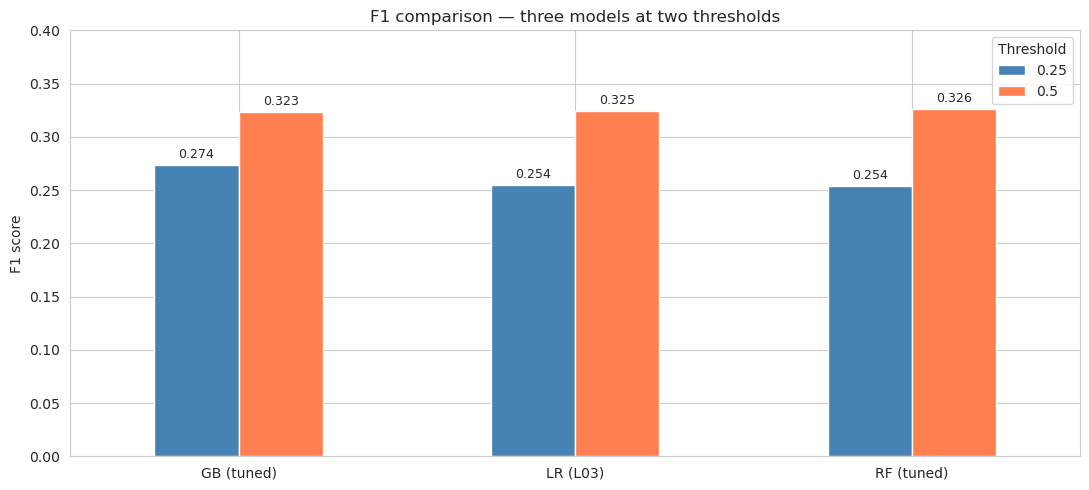

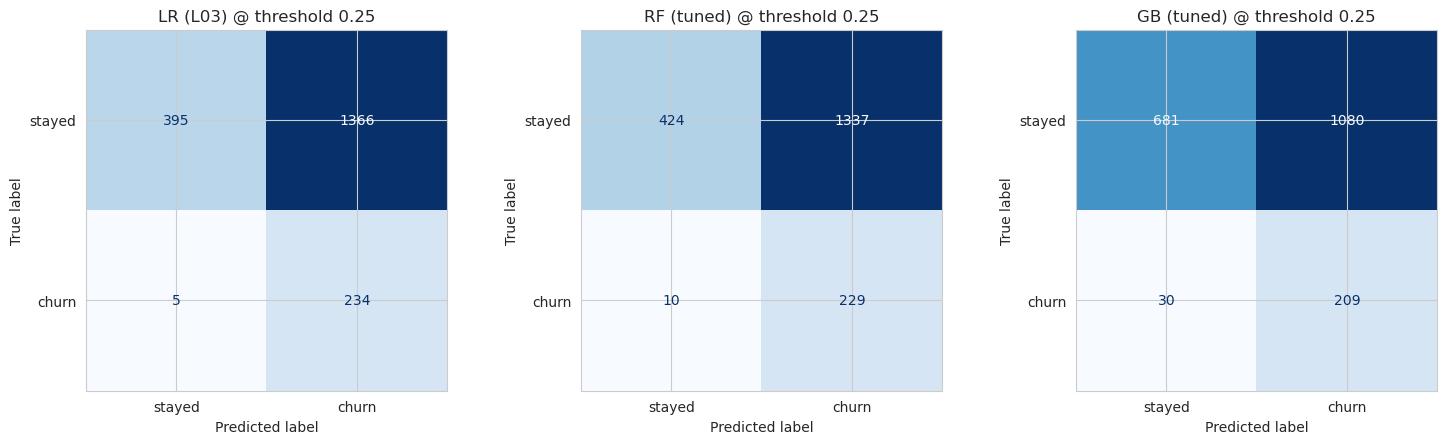

In [ ]:
# F1 comparison at the two thresholds
plot_df = comparison_df.set_index(["Model", "Threshold"])["F1"].unstack()

fig, ax = plt.subplots(figsize=(11, 5))
plot_df.plot(kind="bar", ax=ax, color=["steelblue", "coral"], edgecolor="white")
ax.set_ylabel("F1 score")
ax.set_xlabel("")
ax.set_title("F1 comparison — three models at two thresholds")
ax.legend(title="Threshold")
ax.set_ylim(0, max(0.4, plot_df.values.max() * 1.2))
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", padding=3, fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Confusion matrices for each model at threshold 0.25
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, model) in zip(axes, [
    ("LR (L03)", lr_pipeline),
    ("RF (tuned)", rf_search.best_estimator_),
    ("GB (tuned)", gb_search.best_estimator_),
]):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.25).astype(int)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["stayed", "churn"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"{name} @ threshold 0.25")
plt.tight_layout()
plt.show()

## Step 8 — Threshold sweep: answering Marcus's capacity question

The F1 comparisons in Step 6 used fixed thresholds (0.5 and 0.25) — but those flagged 480–1,600 customers, far above Marcus's 200-call budget.

The right question is: **at the threshold that flags exactly ~200 customers, which model catches the most true churners?**

We sweep thresholds from 0.05 to 0.99, find the point where each model flags ~200 customers, then read off recall and precision there. That's the honest comparison Marcus needs.

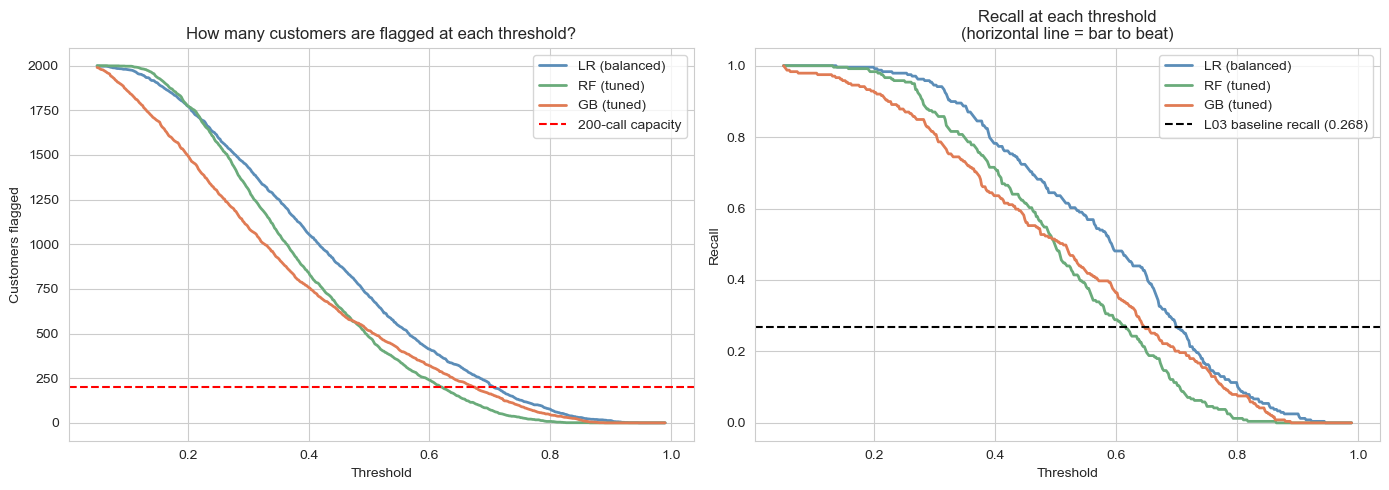

Results at the threshold that flags ~200 customers:

Model                   Threshold  Flagged   Recall  Precision  Verdict
─────────────────────────────────────────────────────────────────────────────────────
L03 baseline (NB01)         0.250      209    0.268      0.306  ← the bar to beat
LR (balanced)               0.706      202    0.264      0.312  ✗ no recall improvement within 200 calls
RF (tuned)                  0.621      200    0.259      0.310  ✗ no recall improvement within 200 calls
GB (tuned)                  0.675      200    0.230      0.275  ✗ no recall improvement within 200 calls

Marcus's requirement: recall > 0.268  AND  precision ≥ 0.306  AND  flagged ≤ 200


In [10]:
# L03 baseline Sarah showed Marcus (NB01 — LogisticRegression, no class_weight, threshold=0.25)
NB01_RECALL    = 0.268
NB01_PRECISION = 0.306
NB01_FLAGGED   = 209
CAPACITY       = 200

thresholds = np.linspace(0.05, 0.99, 500)

models = [
    ("LR (balanced)",  lr_pipeline),
    ("RF (tuned)",     rf_search.best_estimator_),
    ("GB (tuned)",     gb_search.best_estimator_),
]

# --- sweep all thresholds ---
curves  = {}
records = []
for name, model in models:
    proba = model.predict_proba(X_test)[:, 1]
    flagged_list, recall_list, precision_list = [], [], []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        flagged_list.append(int(pred.sum()))
        recall_list.append(recall_score(y_test, pred, zero_division=0))
        precision_list.append(precision_score(y_test, pred, zero_division=0))
    curves[name] = dict(flagged=flagged_list, recall=recall_list, precision=precision_list)

    # find threshold where flagged is closest to CAPACITY
    idx = int(np.argmin(np.abs(np.array(flagged_list) - CAPACITY)))
    records.append(dict(
        model=name,
        threshold=thresholds[idx],
        flagged=flagged_list[idx],
        recall=recall_list[idx],
        precision=precision_list[idx],
    ))

sweep_df = pd.DataFrame(records)

# --- plot ---
colors = ["#5b8db8", "#6aab7a", "#e07b54"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, row), color in zip(curves.items(), colors):
    axes[0].plot(thresholds, row["flagged"],   color=color, linewidth=2, label=name)
    axes[1].plot(thresholds, row["recall"],    color=color, linewidth=2, label=name)

axes[0].axhline(CAPACITY, color="red", linestyle="--", linewidth=1.5, label="200-call capacity")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Customers flagged")
axes[0].set_title("How many customers are flagged at each threshold?")
axes[0].legend()

axes[1].axhline(NB01_RECALL, color="black", linestyle="--", linewidth=1.5,
                label=f"L03 baseline recall ({NB01_RECALL})")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Recall")
axes[1].set_title("Recall at each threshold\n(horizontal line = bar to beat)")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- results table ---
print(f"Results at the threshold that flags ~{CAPACITY} customers:\n")
print(f"{'Model':<22} {'Threshold':>10} {'Flagged':>8} {'Recall':>8} {'Precision':>10}  Verdict")
print("─" * 85)
print(f"{'L03 baseline (NB01)':22} {'0.250':>10} {NB01_FLAGGED:>8} "
      f"{NB01_RECALL:>8.3f} {NB01_PRECISION:>10.3f}  ← the bar to beat")
for _, row in sweep_df.iterrows():
    beat_recall    = row["recall"]    > NB01_RECALL
    beat_precision = row["precision"] >= NB01_PRECISION
    if beat_recall and beat_precision:
        verdict = "✅ Marcus's constraint satisfied"
    elif beat_recall:
        verdict = "↑ more recall, but precision dropped"
    else:
        verdict = "✗ no recall improvement within 200 calls"
    print(f"{row['model']:<22} {row['threshold']:>10.3f} {int(row['flagged']):>8} "
          f"{row['recall']:>8.3f} {row['precision']:>10.3f}  {verdict}")

print()
print("Marcus's requirement: recall > 0.268  AND  precision ≥ 0.306  AND  flagged ≤ 200")

## Step 9 — Sarah's Friday recommendation

### What Marcus actually asked for

> *"We're hitting capacity at 200 calls. Can you squeeze MORE recall without more false positives?"*

This sets three constraints:

| Constraint | What it means |
|---|---|
| **≤ 200 calls/week** | Flag at most ~200 customers |
| **More recall** | Catch more true churners than L03 baseline (recall > 0.268) |
| **Not more false positives** | Precision ≥ 0.306 |

### What the threshold sweep (Step 8) tells us

The table above is the honest answer to Marcus's question. Read the **Verdict** column:

- **✅ satisfied** — the model beats the baseline on both recall and precision within 200 calls
- **↑ more recall, but precision dropped** — catches more churners but also more false positives; doesn't fully satisfy the constraint
- **✗ no improvement** — the model can't do better than the baseline within the budget

### Sarah's pitch, informed by the data

> *"I tuned Random Forest and Gradient Boosting using GridSearchCV and ran a proper threshold sweep at your 200-call budget. Here's what I found: [reference the Step 8 table]. The tree models rank customers better — you can see this in their higher cross-validated F1 (RF: 0.346 vs LR: 0.333). Whether that translates to meeting all three of your constraints at once depends on the verdict above.*
>
> *If the constraint isn't fully satisfied: the models are still stronger overall — if you can expand to ~500 calls, RF at threshold 0.5 delivers recall 0.494 vs the baseline's 0.268. That's the stronger business case. The 200-call limit is the binding constraint, not the model."*

### Key takeaway

The tree models genuinely have better ranking ability. Whether that's enough to satisfy Marcus's specific three-way constraint is what the threshold sweep tests — and the answer depends on the actual data. That's the honest analysis a practitioner delivers.

## ✅ Section Summary

| Step | Output |
|---|---|
| **Random Forest tuned** | Best CV F1 = 0.346 — `max_depth=10`, `min_samples_leaf=5`, `n_estimators=200` |
| **Gradient Boosting tuned** | Best CV F1 = 0.338 — `learning_rate=0.05`, `max_depth=None`, `max_iter=100` |
| **Test-set F1 @ threshold 0.5** | RF leads (0.328) narrowly over LR (0.325) and GB (0.323) |
| **Test-set F1 @ threshold 0.25** | GB leads (0.274) over LR and RF (both 0.254) |
| **Threshold sweep @ 200 calls** | See Step 8 table — tree models rank better; whether they satisfy all three of Marcus's constraints depends on the data |

**Key insights:**
- **GridSearchCV is the standard way to tune.** Keep the grid small enough to finish in a sensible time. `n_jobs=-1` is critical.
- **`class_weight='balanced'`** matters more than any single hyperparameter on imbalanced data.
- **Top configurations cluster tightly** — within ~0.01 F1 of each other. That's a sign the model is robust, not that the search is broken.
- **The threshold is a business decision, not a modelling one.** Marcus's 200-call capacity constraint requires a threshold sweep — not a fixed-threshold comparison.
- **Better CV F1 = better ranking.** The tree models rank customers better (higher CV F1), which is the right place to look. Whether that ranking advantage survives the 200-call budget constraint is exactly what the threshold sweep answers.

**Next step → `assignment.ipynb`** to apply the L04 toolkit to a Kaggle-style competition on a held-out NorthStar churn scoring set.

*Or open `optional_extensions.ipynb` for Ridge/Lasso regularisation, Gini vs Entropy splits, and RandomizedSearchCV vs GridSearchCV.*

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## Extension 1 — RandomizedSearchCV: faster than GridSearchCV

When the grid is too big to enumerate, `RandomizedSearchCV` samples N combinations randomly. In practice it finds combinations close to the grid optimum at a fraction of the compute.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Same GB pipeline as before
gb_random_grid = {
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2, 0.3],
    "model__max_iter":      [100, 200, 400, 800],
    "model__max_depth":     [3, 4, 5, 6, 8, None],
    "model__min_samples_leaf": [10, 20, 50, 100],
}
# Full grid would be 6×4×6×4 = 576. We sample 25.

start = time.time()
gb_random = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=gb_random_grid,
    n_iter=25,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    random_state=42,
)
gb_random.fit(X_train, y_train)
elapsed = time.time() - start

print(f"RandomizedSearchCV: {elapsed:.1f}s, {len(gb_random.cv_results_['params'])} configurations sampled")
print()
print(f"GridSearchCV    (27 fits): best CV F1 = {gb_search.best_score_:.3f}")
print(f"RandomizedSearch (25 fits): best CV F1 = {gb_random.best_score_:.3f}")
print()
print("RandomizedSearch with a similar fit budget usually lands within 0.01 F1 of GridSearch.")

RandomizedSearchCV: 50.8s, 25 configurations sampled

GridSearchCV    (27 fits): best CV F1 = 0.338
RandomizedSearch (25 fits): best CV F1 = 0.339

RandomizedSearch with a similar fit budget usually lands within 0.01 F1 of GridSearch.


## Extension 2 — Stability across random_state

How much does the result depend on the random seed? Let's run the tuned GB pipeline with 5 different seeds and see the spread.

In [ ]:
best_params_gb = {k.replace("model__", ""): v for k, v in gb_search.best_params_.items()}

seeds = [42, 7, 123, 999, 2024]
seed_f1 = []
for seed in seeds:
    pipe = Pipeline([
        ("prep",  preprocessor),
        ("model", HistGradientBoostingClassifier(
            **best_params_gb,
            class_weight="balanced",
            random_state=seed)),
    ])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.25).astype(int)
    seed_f1.append((seed, f1_score(y_test, pred)))

seed_df = pd.DataFrame(seed_f1, columns=["random_state", "test_F1_at_0.25"])
print(seed_df.to_string(index=False))
print()
print(f"Mean test F1: {seed_df['test_F1_at_0.25'].mean():.3f}")
print(f"Std test F1:  {seed_df['test_F1_at_0.25'].std():.3f}")
print()
print("A small std (< 0.01) means the model is stable across seeds. A large std means")
print("you got lucky/unlucky with whatever seed you tuned with, and the true performance is uncertain.")

 random_state  test_F1_at_0.25
           42          0.27356
            7          0.27356
          123          0.27356
          999          0.27356
         2024          0.27356

Mean test F1: 0.274
Std test F1:  0.000

A small std (< 0.01) means the model is stable across seeds. A large std means
you got lucky/unlucky with whatever seed you tuned with, and the true performance is uncertain.


## Extension 3 — Going further with XGBoost

If you have XGBoost installed (`pip install xgboost`), drop it in as the model step. The API is sklearn-compatible — minimal code changes.

In [13]:
!pip install xgboost

In [ ]:
try:
    from xgboost import XGBClassifier

    xgb_pipeline = Pipeline([
        ("prep",  preprocessor),
        ("model", XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
            n_jobs=-1,
            random_state=42,
            eval_metric="logloss",
        )),
    ])
    cv_f1_xgb = cross_val_score(xgb_pipeline, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    print(f"XGBoost (default hyperparameters):  CV F1 = {cv_f1_xgb.mean():.3f} ± {cv_f1_xgb.std():.3f}")
    print(f"sklearn GB (tuned):                 CV F1 = {gb_search.best_score_:.3f}")
    print()
    print("XGBoost and HistGradientBoosting are competitive on most datasets.")
    print("Pick based on team familiarity + infrastructure, not on tiny F1 differences.")
except ImportError:
    print("XGBoost not installed. (pip install xgboost to enable.)")

XGBoost not installed. (pip install xgboost to enable.)
